# Module 2 · Part A — Profiling, cleaning and the data story (`01_eda.ipynb`)

This notebook is step 1 of one continuous pipeline:

1. **Load** the Titanic data **once** with `sns.load_dataset("titanic")` and immediately save it as `titanic.csv` (the offline fallback).
2. **Profile** it and measure missing values.
3. **Clean** it with the threshold rule (rules live in `titanic_cleaning.py`, shared with the modeling notebook).
4. **Explore**: univariate → bivariate → a multi-chart data story → a z-score sanity check.

`02_modeling.ipynb` then continues from the same `titanic.csv` — it never calls `sns.load_dataset` again.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler

from titanic_cleaning import basic_clean, impute_age_for_eda, missing_report

pd.set_option("display.width", 140)

# ---- one consistent chart style for the whole module ----
FEMALE, MALE = "#2a78d6", "#eb6834"          # colour always follows the entity
SURVIVED, DIED = "#1baf7a", "#898781"
SEX_COLORS = {"female": FEMALE, "male": MALE}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.edgecolor": "#898781", "axes.labelcolor": "#52514e", "xtick.color": "#52514e",
    "ytick.color": "#52514e", "axes.titleweight": "bold", "axes.titlesize": 12,
})
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")

## Task 1 — Load once, save the offline fallback, profile

The **only** network load of the raw data in the whole module happens in the next cell. If the internet is unavailable (e.g. at grading time), it falls back to the committed `titanic.csv`.

In [2]:
CSV_PATH = Path("titanic.csv")
try:
    df = sns.load_dataset("titanic")          # the one and only load of the raw dataset
    df.to_csv(CSV_PATH, index=False)          # committed offline fallback
    print("Loaded from seaborn and saved ->", CSV_PATH)
except Exception as err:                      # no internet -> use the committed copy
    print("seaborn load failed:", err)
    df = pd.read_csv(CSV_PATH)
    print("Loaded offline fallback", CSV_PATH)

print("Shape:", df.shape)

Loaded from seaborn and saved -> titanic.csv
Shape: (891, 15)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.select_dtypes(exclude='number').describe()   # the text / category / boolean columns

,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,889,891,891,891,203,889,891,891
unique,2,3,3,3,2,7,3,2,2
top,male,S,Third,man,True,C,Southampton,no,True
freq,577,644,491,537,537,59,644,549,537


In [6]:
miss = missing_report(df)
miss

,missing_count,missing_pct,threshold_rule
deck,688,77.22,> 30 % -> drop column or 'missing' category
age,177,19.87,5-30 % -> impute
embarked,2,0.22,< 5 % -> drop rows
embark_town,2,0.22,< 5 % -> drop rows


In [7]:
balance = df["survived"].value_counts(normalize=True).mul(100).round(1)
print(f"Class balance: died = {balance[0]} %, survived = {balance[1]} %")

Class balance: died = 61.6 %, survived = 38.4 %


**Profile summary.** 891 rows × 15 columns. Four columns have missing values: `deck` 77.22 %, `age` 19.87 %, `embarked` 0.22 % and `embark_town` 0.22 %. The target is imbalanced: about 61.6 % died and 38.4 % survived, which matters later for the stratified split.

## Task 2 — Missing-value handling with the threshold rule

| Column | Missing (measured) | Rule band | Decision |
|---|---|---|---|
| `embarked` | **0.22 %** (2 rows) | < 5 % | **Drop the 2 rows.** Removing 0.22 % of the data cannot bias the results. |
| `embark_town` | **0.22 %** (same 2 rows) | < 5 % | **Drop** — the same 2 passengers; `embark_town` is just the long name of `embarked`. |
| `age` | **19.87 %** (177 rows) | 5 – 30 % | **Impute** with the median age of passengers of the **same sex and class**. Age differs a lot by class (1st-class passengers are older), so a group median is more realistic than one overall median; the median is used because it ignores extreme ages. |
| `deck` | **77.22 %** (688 rows) | > 30 % | Too much is missing to impute reliably (we would be inventing 3 out of 4 values). **Decision: encode missing as its own category `"Unknown"`** rather than dropping the column. Reason: the gaps are *not random* — deck was mostly recorded for 1st-class passengers, so “Unknown” itself carries information (passengers with a known deck survived at ~67 % vs ~30 % for “Unknown”, shown below). Dropping the column would throw that signal away. |

The rules for `embarked`, `embark_town` and `deck` are fixed rules that learn nothing from the data (`basic_clean`), so the modeling notebook can safely reuse them. The age median is learned from data, so it is applied here for EDA only; the modeling pipeline learns its own imputation value from the training split only.

In [8]:
df_clean = impute_age_for_eda(basic_clean(df))

print("Rows before:", len(df), "-> after:", len(df_clean))
print("Missing values left:", int(df_clean.isna().sum().sum()))
print("\nSurvival rate: deck known vs 'Unknown'")
print(df_clean.groupby(df_clean["deck"].eq("Unknown").map({True: "deck Unknown", False: "deck known"}))["survived"]
      .mean().round(3).to_string())

Rows before: 891 -> after: 889
Missing values left: 0

Survival rate: deck known vs 'Unknown'
deck
deck Unknown    0.299
deck known      0.667


## Task 3 — Univariate analysis: `age` and `fare`

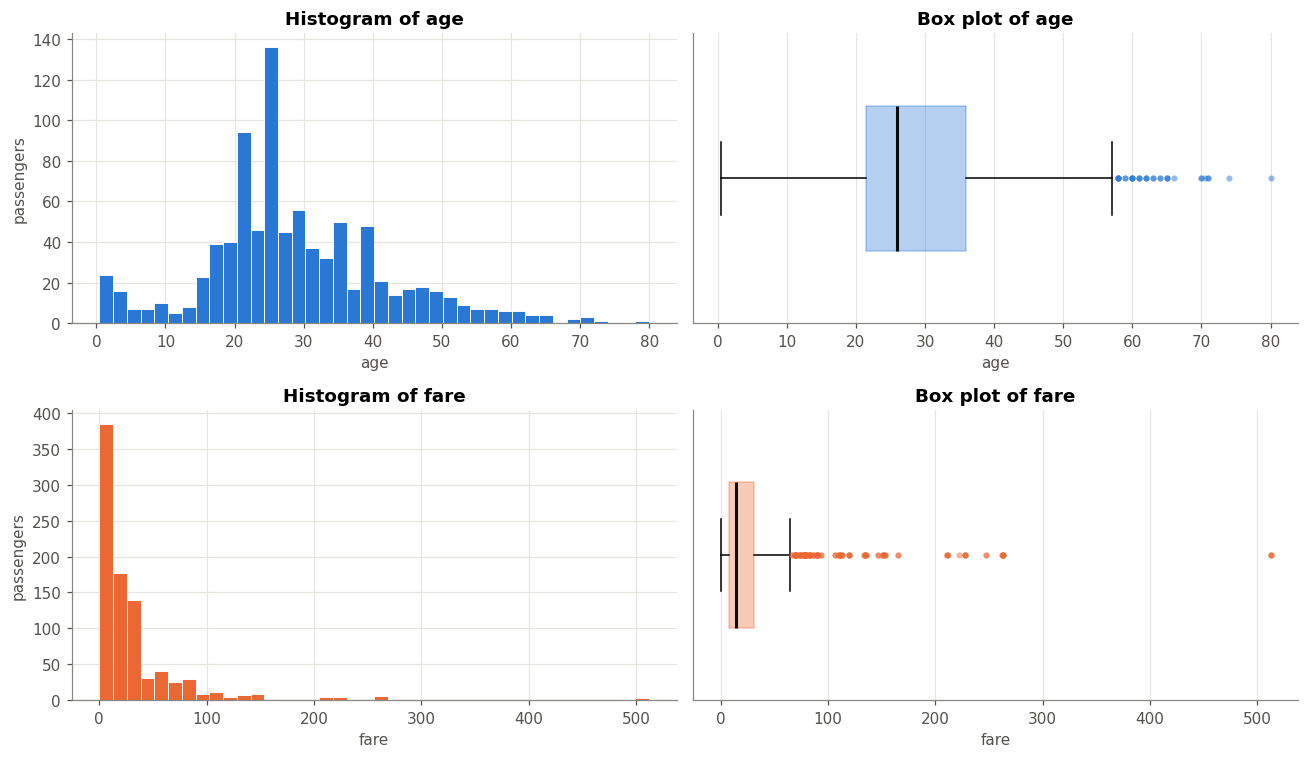

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, col, color in [(0, "age", FEMALE), (1, "fare", MALE)]:
    axes[row, 0].hist(df_clean[col], bins=40, color=color, edgecolor="white", linewidth=0.6)
    axes[row, 0].set(title=f"Histogram of {col}", xlabel=col, ylabel="passengers")
    axes[row, 1].boxplot(df_clean[col], vert=False, widths=0.5, patch_artist=True,
                         boxprops=dict(facecolor=color, alpha=0.35, edgecolor=color),
                         medianprops=dict(color="#0b0b0b", linewidth=2),
                         flierprops=dict(marker="o", markersize=4, markerfacecolor=color, alpha=0.5, markeredgecolor="none"))
    axes[row, 1].set(title=f"Box plot of {col}", xlabel=col, yticks=[])
fig.tight_layout()
save(fig, "01_univariate_age_fare")
plt.show()

In [10]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((series < low) | (series > high)).sum())
    return {"Q1": round(q1, 2), "Q3": round(q3, 2), "IQR": round(iqr, 2),
            "lower_fence": round(low, 2), "upper_fence": round(high, 2), "outliers": n,
            "outlier_pct": round(100 * n / len(series), 1)}

outliers = pd.DataFrame({
    "age (cleaned, after imputation)": iqr_outliers(df_clean["age"]),
    "age (raw, known ages only)": iqr_outliers(df["age"].dropna()),
    "fare": iqr_outliers(df_clean["fare"]),
}).T
outliers

,Q1,Q3,IQR,lower_fence,upper_fence,outliers,outlier_pct
"age (cleaned, after imputation)",21.50,36.0,14.50,-0.25,57.75,32.0,3.6
"age (raw, known ages only)",20.12,38.0,17.88,-6.69,64.81,11.0,1.5
fare,7.90,31.0,23.10,-26.76,65.66,114.0,12.8


In [11]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]
print(f"fare  mean = {fare_mean:.2f}   median = {fare_median:.2f}   mode = {fare_mode:.2f}")
print(f"skewness coefficient = {df_clean['fare'].skew():.2f}")
print("Ordering mode < median < mean ->", fare_mode < fare_median < fare_mean)

fare  mean = 32.10   median = 14.45   mode = 8.05
skewness coefficient = 4.80
Ordering mode < median < mean -> True


**Outliers (IQR rule).** On the cleaned data, `age` has **32** outliers — all above the upper fence of 57.75 years (older passengers), since the lower fence is negative. On the raw known ages only, the count is **11** (above 64.8 years): the group-median imputation packs many values into the middle, which shrinks the IQR and makes more ages look extreme. `fare` has **114** outliers (12.8 % of passengers), all above £65.66 — mostly expensive 1st-class tickets, up to £512.33. These are real prices, not errors, so they are kept.

**Skewness of `fare`.** mode (£8.05) < median (£14.45) < mean (£32.10). When the mean is pulled far above the median and the mode sits lowest, a long tail of large values is dragging the mean to the right, so **`fare` is strongly right-skewed** (skewness ≈ 4.8). Most people paid a cheap 3rd-class fare, while a few very expensive tickets form the long right tail — exactly what the histogram and the box plot show.

## Task 4 — Bivariate analysis

### Survival rate with boolean masks (`&` and `|`)

In [12]:
d = df_clean

# (a) by sex
by_sex = {s: d.loc[d["sex"] == s, "survived"].mean() for s in ["female", "male"]}

# (b) by passenger class
by_class = {p: d.loc[d["pclass"] == p, "survived"].mean() for p in [1, 2, 3]}

# (c) by sex AND class together  -> two conditions combined with &
by_sex_class = {(s, p): d.loc[(d["sex"] == s) & (d["pclass"] == p), "survived"].mean()
                for s in ["female", "male"] for p in [1, 2, 3]}

print("(a) Survival rate by sex")
for s, r in by_sex.items():
    print(f"    {s:<7} {r:6.1%}")
print("\n(b) Survival rate by class")
for p, r in by_class.items():
    print(f"    class {p}  {r:6.1%}")
print("\n(c) Survival rate by sex & class  (mask: (sex == s) & (pclass == p))")
print(pd.Series(by_sex_class).unstack().rename(columns=lambda p: f"class {p}")
        .map(lambda r: f"{r:.1%}").to_string())

# Bonus: an OR (|) mask — "women OR children under 16" vs everyone else
women_or_child = (d["sex"] == "female") | (d["age"] < 16)
print(f"\nWomen OR children (<16): {d.loc[women_or_child, 'survived'].mean():.1%}"
      f"   vs  adult men: {d.loc[~women_or_child, 'survived'].mean():.1%}")

(a) Survival rate by sex
    female   74.0%
    male     18.9%

(b) Survival rate by class
    class 1   62.6%
    class 2   47.3%
    class 3   24.2%

(c) Survival rate by sex & class  (mask: (sex == s) & (pclass == p))
       class 1 class 2 class 3
female   96.7%   92.1%   50.0%
male     36.9%   15.7%   13.5%

Women OR children (<16): 71.6%   vs  adult men: 16.4%


**Reading the numbers.** Sex is the single biggest divider: **74.0 %** of women survived vs **18.9 %** of men. Class matters too: **62.6 %** (1st) → **47.3 %** (2nd) → **24.2 %** (3rd). Combining them shows the two effects stack: women in 1st and 2nd class almost all survived (**96.7 %** and **92.1 %**) while 3rd-class women had a coin-flip chance (**50.0 %**); for men, 1st class gave **36.9 %** but 2nd and 3rd class only **15.7 %** and **13.5 %**. The `|` mask confirms “women and children first”: women or children under 16 survived at about **71 %** vs about **16 %** for adult men.

### Correlation matrix — exactly the 6 numeric columns (`adult_male` and `alone` excluded)

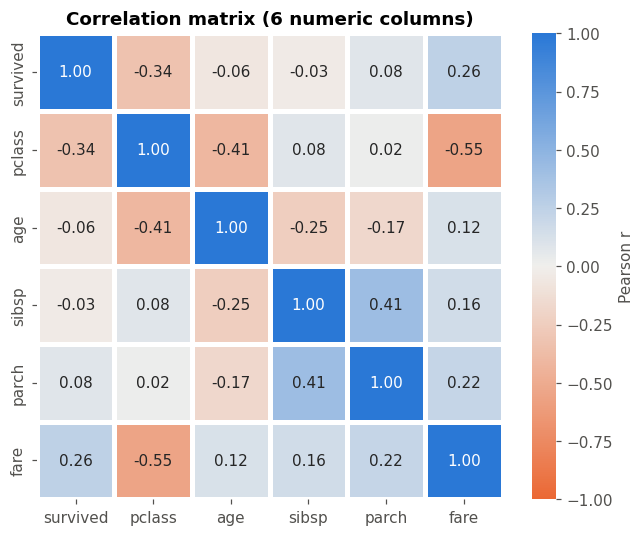

Off-diagonal pairs ranked by |correlation|:


r  abs_r
pclass   fare   -0.548  0.548
sibsp    parch   0.415  0.415
pclass   age    -0.411  0.411
survived pclass -0.336  0.336
         fare    0.255  0.255
age      sibsp  -0.249  0.249
parch    fare    0.218  0.218
age      parch  -0.175  0.175
sibsp    fare    0.161  0.161
age      fare    0.120  0.120
survived parch   0.083  0.083
pclass   sibsp   0.082  0.082
survived age    -0.064  0.064
         sibsp  -0.034  0.034
pclass   parch   0.017  0.017

In [13]:
CORR_COLS = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = d[CORR_COLS].corr()

diverging = LinearSegmentedColormap.from_list("div", ["#eb6834", "#f0efec", "#2a78d6"])
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=diverging, vmin=-1, vmax=1, center=0,
            square=True, linewidths=2, linecolor="white", cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation matrix (6 numeric columns)")
save(fig, "02_correlation_heatmap")
plt.show()

# Rank every off-diagonal pair (upper triangle only, so each pair counts once) by |r|
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().dropna()
ranked = (upper.rename("r").to_frame().assign(abs_r=lambda t: t["r"].abs())
               .sort_values("abs_r", ascending=False).round(3))
print("Off-diagonal pairs ranked by |correlation|:")
ranked

**The two strongest correlations** (largest |r| among off-diagonal pairs):

1. **`pclass` ↔ `fare`, r = −0.55.** A negative link: as the class number goes *up* (1 → 3, i.e. a cheaper class) the fare goes *down*. This is almost by definition — a 1st-class ticket costs much more — and it means `pclass` and `fare` partly carry the same “wealth” information, which a model should keep in mind.
2. **`sibsp` ↔ `parch`, r = +0.41.** Passengers travelling with siblings/spouses also tend to travel with parents/children — both columns measure *family travelling together*, so large families score high on both.

(`pclass` ↔ `age` is a close third at r = −0.41: 1st-class passengers tended to be older.) For the target, `survived` correlates most with `pclass` (r = −0.34) and `fare` (r = +0.26): richer passengers survived more often. Note that `sex`, the strongest predictor, is not in this matrix because it is not numeric.

## Task 5 — The data story: *who survived, and why?*

Five charts, each building on the last.

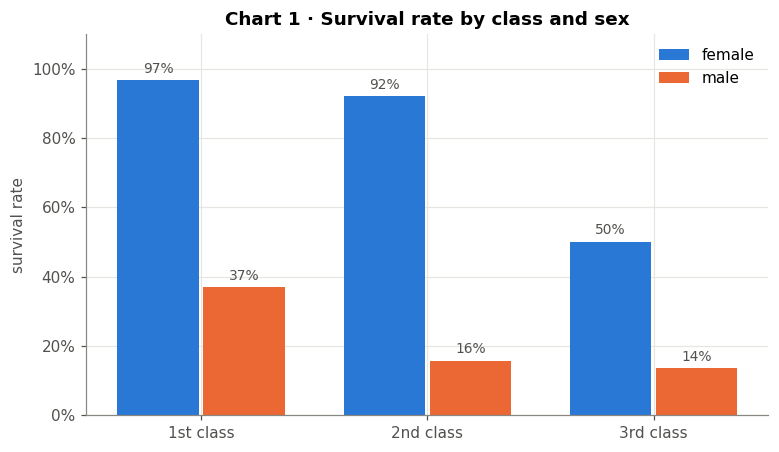

In [14]:
# Chart 1 — survival rate by class, split by sex
rates = d.groupby(["pclass", "sex"])["survived"].mean().unstack()
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(3); w = 0.38
for i, sex in enumerate(["female", "male"]):
    bars = ax.bar(x + (i - 0.5) * w, rates[sex], width=w - 0.02, color=SEX_COLORS[sex], label=sex)
    ax.bar_label(bars, labels=[f"{v:.0%}" for v in rates[sex]], padding=3, fontsize=9, color="#52514e")
ax.set(xticks=x, xticklabels=["1st class", "2nd class", "3rd class"], ylabel="survival rate", ylim=(0, 1.1),
       title="Chart 1 · Survival rate by class and sex")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(frameon=False)
save(fig, "03_story_class_sex"); plt.show()

**Chart 1 — Sex first, then class.** In every class women survived far more often than men, which is the “women and children first” rule of the lifeboats in action. Class then sharpens the gap: 1st- and 2nd-class women were almost all saved (97 % and 92 %), while 3rd-class women had only a 50 % chance. For men, only 1st class gave a real advantage (37 % vs ~14–16 %). Sex sets the baseline and class moves it up or down.

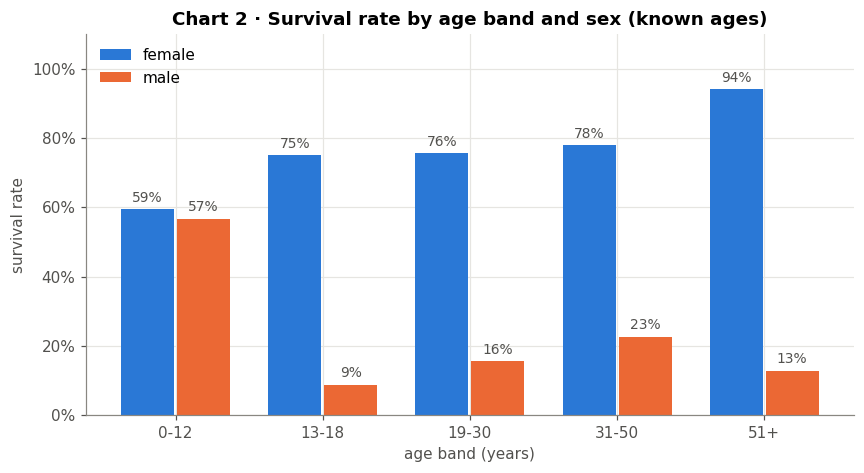

Passengers per band:
 sex       female  male
age_band              
0-12          32    37
13-18         36    34
19-30         90   180
31-50         86   155
51+           17    47


In [15]:
# Chart 2 — survival rate by age band, split by sex (uses the RAW known ages to avoid imputation spikes)
known = df.dropna(subset=["age"]).copy()
bands = [0, 12, 18, 30, 50, 81]
labels = ["0-12", "13-18", "19-30", "31-50", "51+"]
known["age_band"] = pd.cut(known["age"], bins=bands, labels=labels, right=True, include_lowest=True)
age_rates = known.groupby(["age_band", "sex"], observed=True)["survived"].mean().unstack()
age_n = known.groupby(["age_band", "sex"], observed=True).size().unstack()

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(labels)); w = 0.38
for i, sex in enumerate(["female", "male"]):
    bars = ax.bar(x + (i - 0.5) * w, age_rates[sex], width=w - 0.02, color=SEX_COLORS[sex], label=sex)
    ax.bar_label(bars, labels=[f"{v:.0%}" for v in age_rates[sex]], padding=3, fontsize=9, color="#52514e")
ax.set(xticks=x, xticklabels=labels, xlabel="age band (years)", ylabel="survival rate", ylim=(0, 1.1),
       title="Chart 2 · Survival rate by age band and sex (known ages)")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(frameon=False)
save(fig, "04_story_age_sex"); plt.show()
print("Passengers per band:\n", age_n.to_string())

**Chart 2 — Being a child mainly helped boys.** Boys aged 0–12 survived at **57 %**, while every older male group survived at only **9–23 %** — once a boy was treated as a man (13+), his chances collapsed. For females the pattern is reversed: adult women survived at **75–94 %**, but girls aged 0–12 only at **59 %**, probably because many young children travelled in large 3rd-class families (see Chart 4). So “women and children first” was real, but the “children” part mostly shows up for boys. (Known ages only, so the imputed medians do not create a fake spike in one band.)

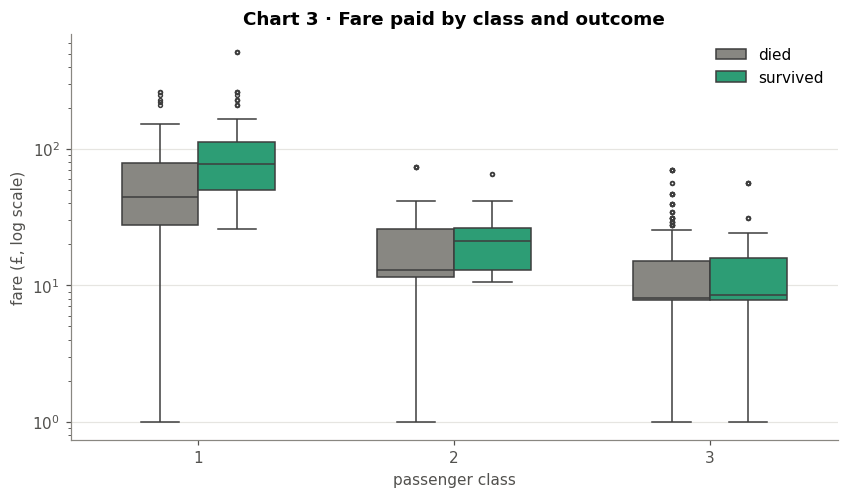

survived  median fare died  median fare survived
pclass                                          
1                    44.75              77.34375
2                    13.00              21.00000
3                     8.05               8.51670


In [16]:
# Chart 3 — fare paid, by class and outcome (log scale because fare is very right-skewed)
fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = d.assign(outcome=d["survived"].map({0: "died", 1: "survived"}), fare_plot=d["fare"].clip(lower=1))
sns.boxplot(data=plot_df, x="pclass", y="fare_plot", hue="outcome", hue_order=["died", "survived"],
            palette={"died": DIED, "survived": SURVIVED}, width=0.6, fliersize=2.5, linewidth=1, ax=ax)
ax.set_yscale("log")
ax.set(xlabel="passenger class", ylabel="fare (£, log scale)", title="Chart 3 · Fare paid by class and outcome")
ax.legend(title=None, frameon=False)
save(fig, "05_story_fare_class"); plt.show()
print(d.groupby(["pclass", "survived"])["fare"].median().unstack().rename(columns={0: "median fare died", 1: "median fare survived"}))

**Chart 3 — Money mattered, especially in 1st class.** Fare separates the classes cleanly (note the log scale). Inside 1st class, survivors paid a median of about £77 vs £45 for those who died — the most expensive cabins were on the upper decks, closer to the lifeboats. In 3rd class the medians are almost identical (£8.05 vs £8.52): once you were in steerage, paying a little more did not help. Fare adds information beyond class only at the top end.

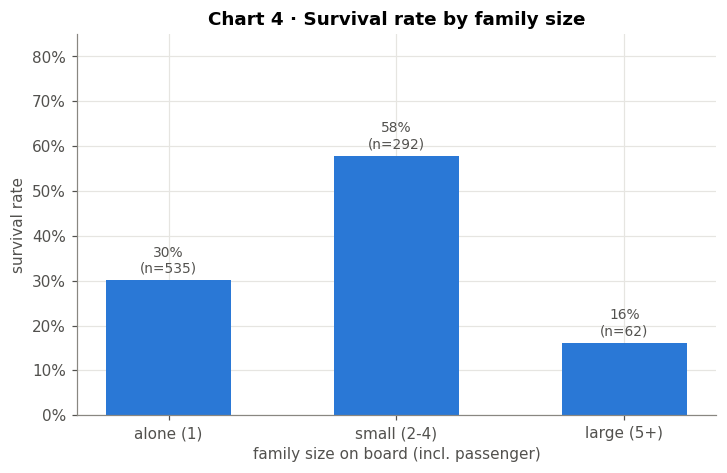

In [17]:
# Chart 4 — family size
fam = d.assign(family_size=d["sibsp"] + d["parch"] + 1)
fam["family_group"] = pd.cut(fam["family_size"], bins=[0, 1, 4, 20], labels=["alone (1)", "small (2-4)", "large (5+)"])
fam_stats = fam.groupby("family_group", observed=True)["survived"].agg(rate="mean", n="size")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(fam_stats.index.astype(str), fam_stats["rate"], width=0.55, color=FEMALE)
ax.bar_label(bars, labels=[f"{r:.0%}\n(n={n})" for r, n in zip(fam_stats["rate"], fam_stats["n"])],
             padding=3, fontsize=9, color="#52514e")
ax.set(ylabel="survival rate", ylim=(0, 0.85), xlabel="family size on board (incl. passenger)",
       title="Chart 4 · Survival rate by family size")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
save(fig, "06_story_family_size"); plt.show()

**Chart 4 — Small families did best.** Passengers travelling alone survived at only about 30 %, small families (2–4 people) at about 58 %, and large families (5+) at only about 16 %. Lone travellers were mostly adult men in 3rd class, which explains their low rate. Large families were almost all in 3rd class and struggled to get everyone to the boats together. Family size is therefore a non-linear signal — the middle group wins — which a tree-based model can capture better than a straight line.

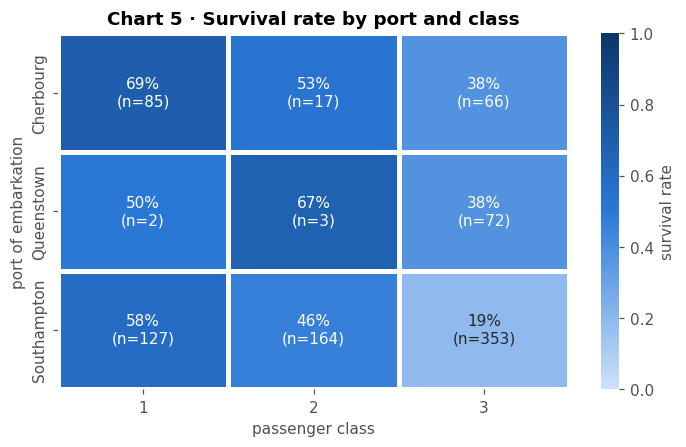

Overall survival by port: {'Cherbourg': 0.554, 'Queenstown': 0.39, 'Southampton': 0.337}


In [18]:
# Chart 5 — port of embarkation x class (heatmap of survival rate + counts)
port_names = {"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"}
pivot_rate = d.pivot_table(index="embarked", columns="pclass", values="survived", aggfunc="mean").rename(index=port_names)
pivot_n = d.pivot_table(index="embarked", columns="pclass", values="survived", aggfunc="size").rename(index=port_names)
annot = pivot_rate.map(lambda r: f"{r:.0%}") + "\n(n=" + pivot_n.astype(int).astype(str) + ")"

seq_blue = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#2a78d6", "#0d366b"])
fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.heatmap(pivot_rate, annot=annot, fmt="", cmap=seq_blue, vmin=0, vmax=1, linewidths=2, linecolor="white",
            cbar_kws={"label": "survival rate"}, ax=ax)
ax.set(xlabel="passenger class", ylabel="port of embarkation", title="Chart 5 · Survival rate by port and class")
save(fig, "07_story_port_class"); plt.show()
print("Overall survival by port:", d.groupby("embarked")["survived"].mean().round(3).rename(index=port_names).to_dict())

**Chart 5 — Much of the port effect is a class effect.** On its own, Cherbourg looks “lucky” (55 % survived vs 34 % from Southampton). But about half of Cherbourg's passengers travelled 1st class, compared with only 20 % of Southampton's, and 94 % of Queenstown's passengers were in 3rd class. Comparing *within the same class* shrinks the gap, although Cherbourg is still ahead (1st class: 69 % vs 58 %; 3rd class: 38 % vs 19 %). A port cannot save anyone by itself, so the remaining gap most likely reflects other differences in who boarded where. Port is a weak, indirect signal compared with sex and class.

**The story in one paragraph.** Survival on the Titanic followed a clear priority: **women and children first, then wealth**. Sex is the strongest single factor (74 % vs 19 %), class multiplies it (1st-class women 97 %, 3rd-class men 14 %), being a child helped mainly boys, higher fares helped within 1st class, and small families did better than lone travellers or large families. Apparent effects such as port of embarkation shrink a lot once class is accounted for. This tells the modeling step which features should matter most: `sex`, `pclass`, `age`, `fare` and family size (`sibsp`, `parch`).

## Task 6 — Exploratory z-score check on `age` and `fare`

z = (x − mean) / std, computed by hand and with `StandardScaler`, on the full cleaned DataFrame. This is **only an EDA sanity check** — the modeling notebook does its own scaling, fitted on the training split only.

In [19]:
z = pd.DataFrame(index=d.index)
for col in ["age", "fare"]:
    z[f"{col}_z"] = (d[col] - d[col].mean()) / d[col].std(ddof=0)     # manual formula

# Cross-check with scikit-learn (StandardScaler also uses the population std, ddof=0)
z_sklearn = StandardScaler().fit_transform(d[["age", "fare"]])
assert np.allclose(z[["age_z", "fare_z"]].to_numpy(), z_sklearn)

before_after = pd.DataFrame({
    "mean (before)": d[["age", "fare"]].mean().values,
    "std (before)": d[["age", "fare"]].std(ddof=0).values,
    "mean (after z)": z.mean().values,
    "std (after z)": z.std(ddof=0).values,
}, index=["age", "fare"]).round(4)
before_after

,mean (before),std (before),mean (after z),std (after z)
age,29.0654,13.2627,0.0,1.0
fare,32.0967,49.6695,0.0,1.0


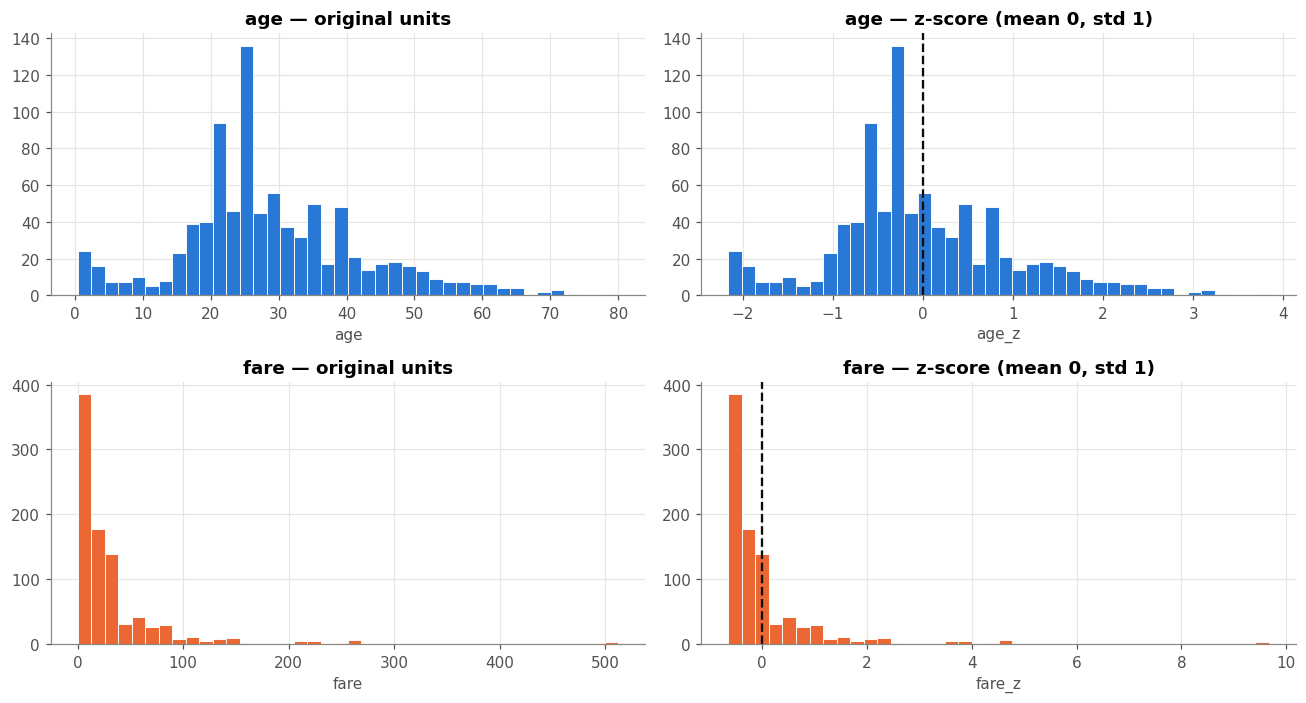

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
for row, col, color in [(0, "age", FEMALE), (1, "fare", MALE)]:
    axes[row, 0].hist(d[col], bins=40, color=color, edgecolor="white", linewidth=0.6)
    axes[row, 0].set(title=f"{col} — original units", xlabel=col)
    axes[row, 1].hist(z[f"{col}_z"], bins=40, color=color, edgecolor="white", linewidth=0.6)
    axes[row, 1].axvline(0, color="#0b0b0b", linewidth=1.5, linestyle="--")
    axes[row, 1].set(title=f"{col} — z-score (mean 0, std 1)", xlabel=f"{col}_z")
fig.tight_layout()
save(fig, "08_zscore_before_after"); plt.show()

**Result.** After the transform both columns have mean ≈ 0 (to 4 decimals) and standard deviation = 1, and the manual formula matches `StandardScaler` exactly. The *shape* of each distribution does not change — `fare` is still right-skewed, only the axis is re-labelled in “standard deviations from the mean”. That is why the z-scored `fare` still has values above +9: standardizing rescales, it does not remove outliers or skew.

➡ **Next:** `02_modeling.ipynb` reads the `titanic.csv` saved above and continues into the modeling pipeline.